# Exploratory Data Analysis (EDA)
**Customer Churn Intelligence & Retention Analytics Platform**

This notebook performs a comprehensive, question-driven exploratory data analysis on the Telco Churn dataset.

### Objectives
1. Understand the composition of the customer base.
2. Identify primary drivers of churn.
3. Discover numerical relationships and correlations.
4. Detect and analyze potential outliers.
5. Extract actionable business insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import os

# Add root directory to path to import local modules
sys.path.append(os.path.abspath('..'))
from src.visualization import visualize

warnings.filterwarnings('ignore')
visualize.setup_style()

## Data Loading

In [2]:
# Load the cleaned dataset
df = pd.read_csv('../data/processed/cleaned_telco_churn.csv')

# Ensure target variable is consistent (some versions use churn_value)
if 'churn_value' in df.columns:
    df['churn'] = df['churn_value']

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 27)


,customerid,city,zip_code,latitude,longitude,gender,senior_citizen,partner,dependents,tenure_months,...,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,cltv,churn
0,3668-QPYBK,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239,1
1,9237-HQITU,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701,1
2,9305-CDSKC,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,5372,1
3,7892-POOKP,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003,1
4,0280-XJGEX,Los Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,5340,1


## Section 1: Customer Base Overview
### Business Questions:
* What is the total number of customers?
* What is the global churn rate?
* How is revenue distributed?

In [3]:
total_customers = len(df)
churned = df['churn'].sum()
retained = total_customers - churned
churn_rate = churned / total_customers

print(f"--- Executive Summary ---")
print(f"Total Customers: {total_customers:,}")
print(f"Retained Customers: {retained:,}")
print(f"Churned Customers: {churned:,}")
print(f"Global Churn Rate: {churn_rate:.1%}")
print(f"Avg Monthly Charges: ${df['monthly_charges'].mean():.2f}")
print(f"Avg Tenure: {df['tenure_months'].mean():.1f} months")

--- Executive Summary ---
Total Customers: 7,043
Retained Customers: 5,174
Churned Customers: 1,869
Global Churn Rate: 26.5%
Avg Monthly Charges: $64.76
Avg Tenure: 32.4 months


## Section 2: Churn Overview by Category
### Business Questions:
* Which contract types suffer the most churn?
* How does payment method impact churn?
* Does internet service type matter?

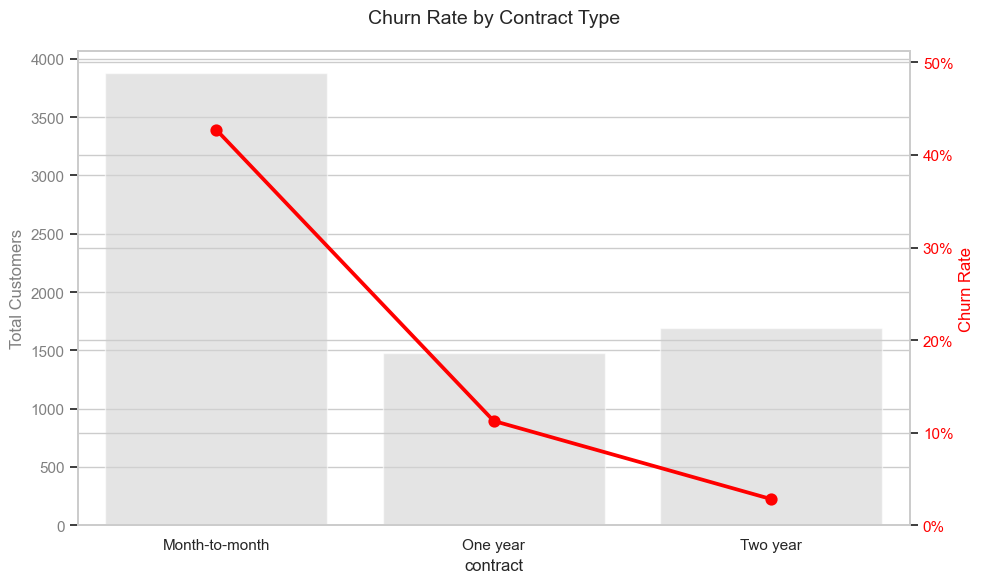

In [4]:
# Churn by Contract
fig1 = visualize.plot_churn_rate_by_category(df, 'contract', title='Churn Rate by Contract Type')
plt.show()

**Observation**: Month-to-month contracts have a drastically higher churn rate (~42%) compared to 1-year and 2-year contracts.
**Business Interpretation**: Long-term commitments heavily lock in customers. Moving customers to annual plans should be a primary retention strategy.

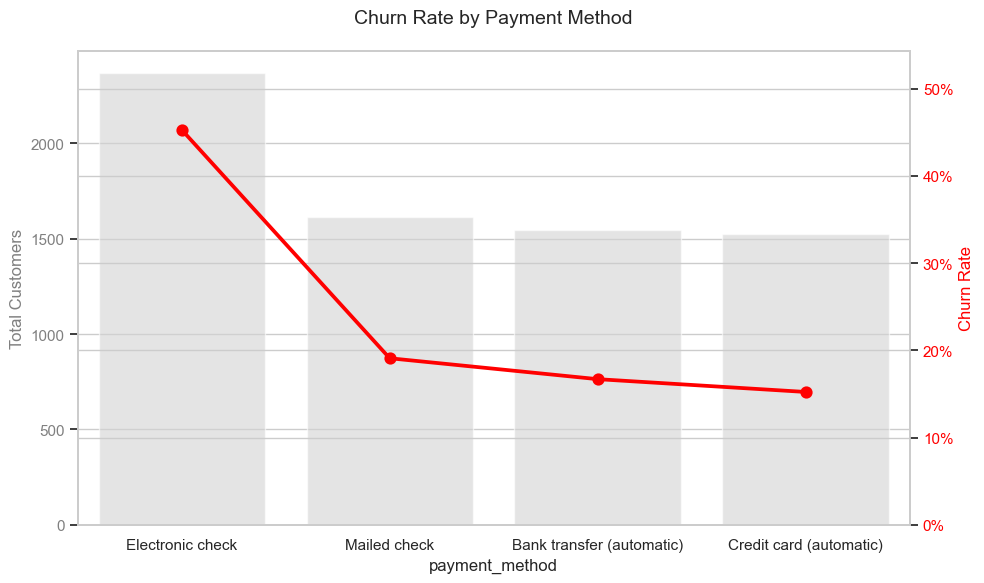

In [5]:
# Churn by Payment Method
fig2 = visualize.plot_churn_rate_by_category(df, 'payment_method', title='Churn Rate by Payment Method')
plt.show()

**Observation**: Electronic check is associated with the highest churn rate (~45%), far above automatic payment methods.
**Business Interpretation**: Friction in payment or the conscious act of paying manually every month reminds customers of the cost, prompting re-evaluation. Pushing automatic payments could reduce churn.

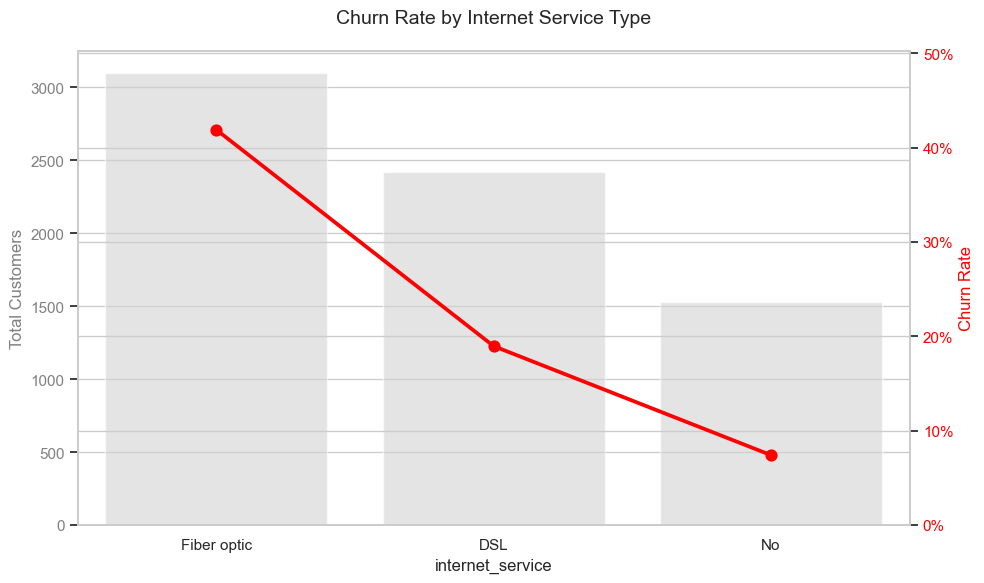

In [6]:
# Churn by Internet Service
fig3 = visualize.plot_churn_rate_by_category(df, 'internet_service', title='Churn Rate by Internet Service Type')
plt.show()

## Section 3: Numerical Analysis
### Business Questions:
* Does tenure differ between churned and retained customers?
* How do monthly charges correlate with churn?

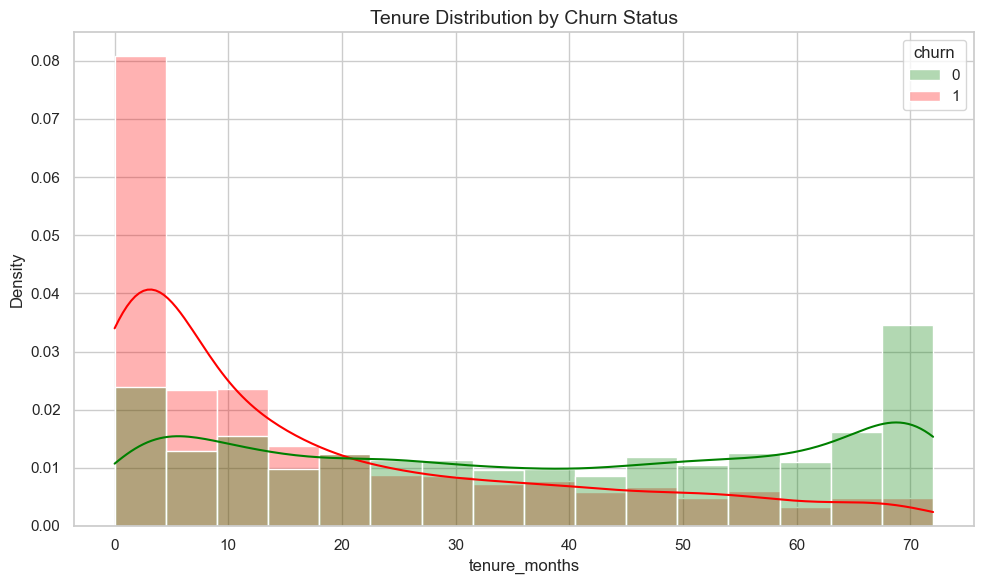

In [7]:
# Tenure Distribution
fig4 = visualize.plot_distribution_by_churn(df, 'tenure_months', title='Tenure Distribution by Churn Status')
plt.show()

**Observation**: Churn is heavily right-skewed, meaning it happens primarily in the first few months. Retained customers show a large peak at the highest tenure.
**Limitation**: This is observational. We don't know if customers stay *because* they are satisfied, or if this is just survivor bias.

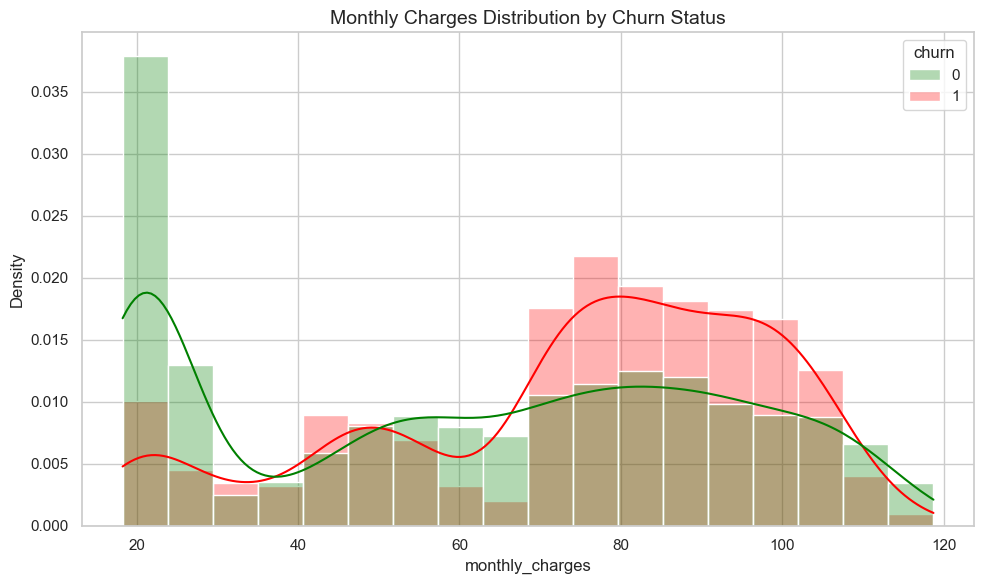

In [8]:
# Monthly Charges Distribution
fig5 = visualize.plot_distribution_by_churn(df, 'monthly_charges', title='Monthly Charges Distribution by Churn Status')
plt.show()

## Section 4: Churn Driver Analysis
Let's rank the categorical features by the absolute difference in churn rate between their categories.

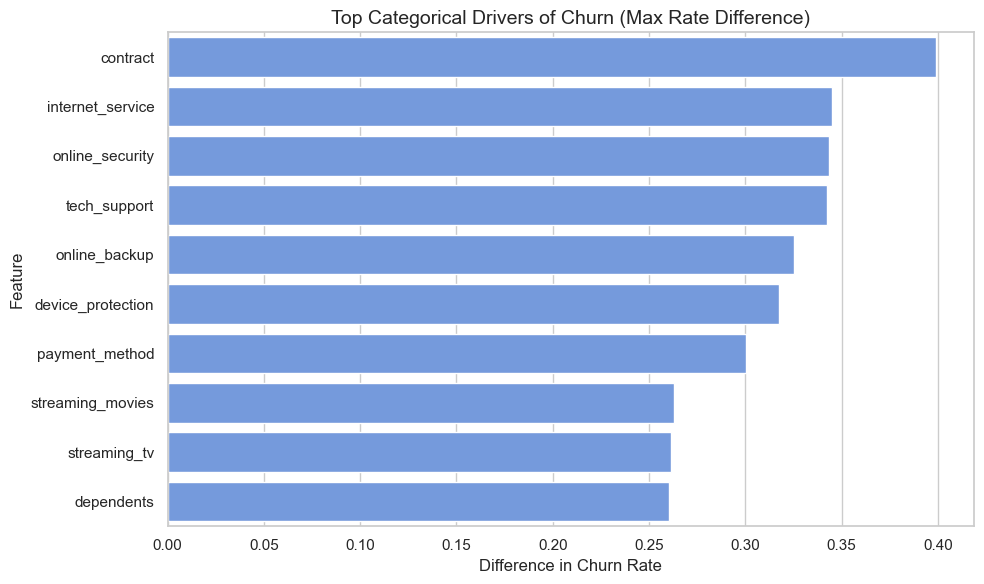

In [9]:
cat_cols = ['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method']

driver_stats = []
for col in cat_cols:
    if col in df.columns:
        rates = df.groupby(col)['churn'].mean()
        max_diff = rates.max() - rates.min()
        driver_stats.append({'Feature': col, 'Max_Churn_Diff': max_diff})

driver_df = pd.DataFrame(driver_stats).sort_values('Max_Churn_Diff', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=driver_df.head(10), y='Feature', x='Max_Churn_Diff', color='cornflowerblue')
plt.title('Top Categorical Drivers of Churn (Max Rate Difference)')
plt.xlabel('Difference in Churn Rate')
plt.tight_layout()
plt.show()

## Section 5: Correlation Analysis
Investigating multicollinearity and linear relationships with churn.

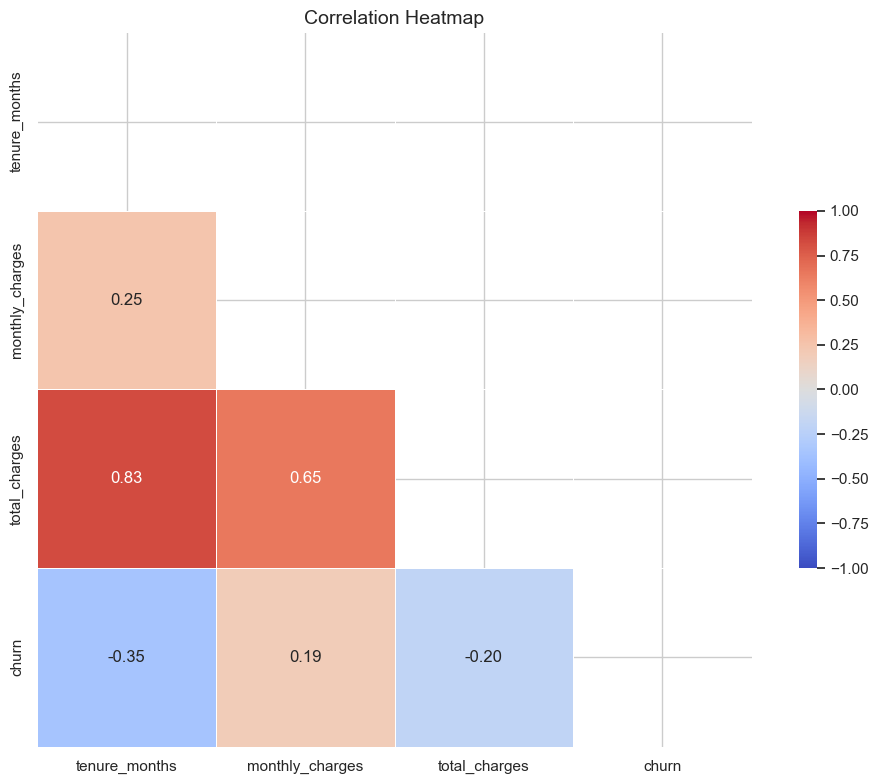

In [10]:
num_cols = ['tenure_months', 'monthly_charges', 'total_charges', 'churn']
# Ensure numeric
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
fig6 = visualize.plot_correlation_heatmap(df, num_cols)
plt.show()

**Observation**: `tenure` and `total_charges` are highly correlated (0.83).
**Business Interpretation**: This is expected since total = monthly * tenure. We may need to drop `total_charges` during modeling to prevent multicollinearity.

## Section 6: Outlier Investigation
Are there any extreme values in monthly charges or tenure?

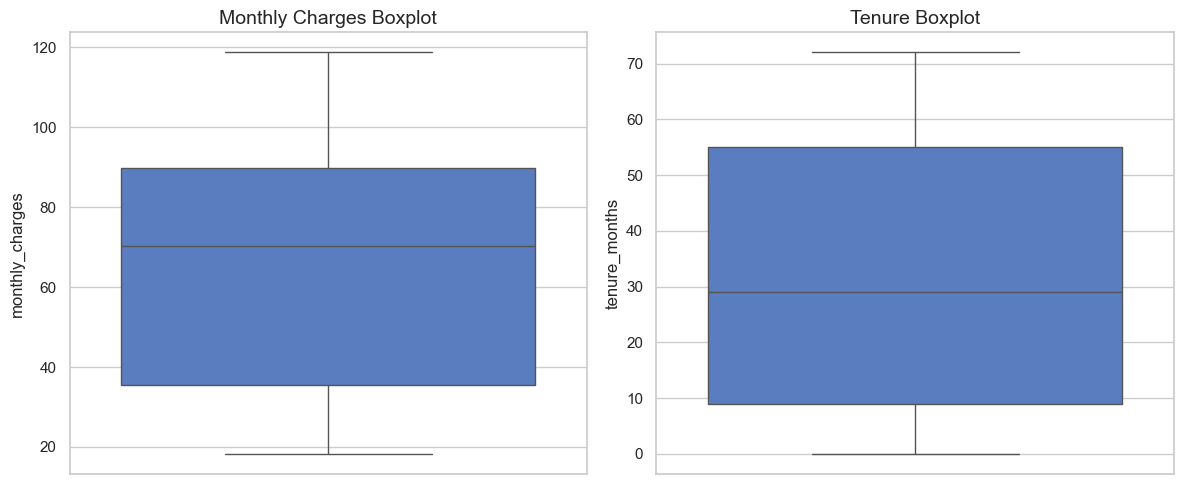

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, y='monthly_charges', ax=ax1)
ax1.set_title('Monthly Charges Boxplot')

sns.boxplot(data=df, y='tenure_months', ax=ax2)
ax2.set_title('Tenure Boxplot')

plt.tight_layout()
plt.show()

**Observation**: There are no statistical outliers beyond the whiskers in either `monthly_charges` or `tenure_months`.
**Interpretation**: The data falls within expected bounded ranges (tenure max ~72 months, charges max ~$120). No outlier removal or clipping is necessary.